# European Steel Decarbonization
## Action Score Framework

**Team:** SuSteelAible  
**Author:** Irene  
**Date:** December 2024  

---

## What is the Action Score?

We developed the Action Score to assess decarbonization effort and readiness among European steel companies. Our framework captures both **current performance** and **future positioning**, distinguishing companies that are actively transforming from those optimizing legacy technologies.

**Total Score:** 100 points (5 components)

## Assessment Period

This notebook evaluates companies based on data through **2024**, with components using different temporal windows:
- **Performance:** Most recent year (2024)
- **Trend:** All available years (2013-2024)
- **Data Quality:** Full reporting history
- **Technology & Renewable:** 2020-2024 period status

A separate temporal analysis notebook explores pre/post-COVID period comparison.

---

## The Five Components

### 1. Performance (30 points)
**What:** Current emissions intensity (Scope 1+2)  
**Metric:** How clean is the company **today**?  
**Benchmark:** 2.0 tCO₂e/t (typical inefficient BF-BOF)

### 2. Trend (30 points)
**What:** Rate of improvement over time  
**Metric:** Annual % reduction in emissions intensity  
**Threshold:** -2% per year (Science-Based Targets aligned)  
**Filter:** R² ≥ 0.5 (trend must be real, not noise)

### 3. Data Quality (15 points)
**What:** Reporting completeness and transparency  
**Metric:** Time series length + data availability  
**Rationale:** Transparency enables accountability

### 4. Technology (20 points)
**What:** Current technology and transformation plans  
**Range:** 0 pts (no plans) → 20 pts (clean tech at scale)  
**Focus:** Operational pilots, secured funding, and concrete timelines

### 5. Renewable Procurement (0-5 points)
**What:** Active sourcing of renewable electricity (EAF companies only)  
**Range:** 0 pts (<10%) → 5 pts (≥80%)  
**Rationale:** For EAF, renewables are the primary decarbonization lever

---

Let's build the scores.

## 1. Setup & Data Loading

In [1]:
# Setup
import sys
from pathlib import Path

# Add scripts folder to path
scripts_path = Path.cwd().parent / 'scripts'
sys.path.insert(0, str(scripts_path))

In [2]:
# Import libraries
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Import custom data loader
from data_loader import (
    load_company_data,
    load_eu_data,
    load_global_data,
    filter_complete_data,
    prepare_analysis_dataset,
    print_data_summary
)


In [3]:
# Load and prepare data using data_loader
df_raw = load_company_data(fix_apostrophes=True, filter_region='Europe')
df_filtered = filter_complete_data(df_raw, min_years=4) # At least 4 years for scoring
df_analysis = prepare_analysis_dataset(df_filtered)
print_data_summary(df_analysis)

# Load EU and global context data
eu_data = load_eu_data()
global_data = load_global_data()
print(f"✓ EU benchmark data loaded")
print(f"✓ Global benchmark data loaded")

# Settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

# Get list of companies
companies = sorted(df_analysis['company'].unique())
print(f"\nCompanies to score:")
for company in companies:
    n_years = len(df_analysis[df_analysis['company'] == company])
    print(f"  • {company} ({n_years} years)")

   ℹ️  Filtered out 4 rows with missing Scope 1 data
--------------------------------------------------------------------------------
DATASET SUMMARY
--------------------------------------------------------------------------------

🏭 Companies: 13
📂 Total rows: 103
📅 Year range: 2013-2024

Technologies: BF-BOF, EAF, EAF Stainless
Countries: Austria, Bulgaria-Greece, Finland, Germany, Italy, Luxembourg, Netherlands, Spain, Sweden, UK
--------------------------------------------------------------------------------
✓ EU benchmark data loaded
✓ Global benchmark data loaded

Companies to score:
  • Acciaierie d'Italia Holding (4 years)
  • Acerinox EU (6 years)
  • ArcelorMittal (12 years)
  • Celsa Group (5 years)
  • Feralpi Group (12 years)
  • Outokumpu (12 years)
  • SHS Group (8 years)
  • SIDENOR Group (5 years)
  • SSAB (12 years)
  • Salzgitter AG (9 years)
  • Tata Steel Nederland (6 years)
  • Tata Steel UK (5 years)
  • Voestalpine (7 years)


c:\Users\irene\Documents\neue_fische\susteelaible\scripts\data_loader.py:295: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['scope2_method_used'] = df.groupby('company').apply(


## 2. Component 1: Performance (30 points)

**What it measures:** Current emissions intensity (how clean the company is TODAY)

**Formula:** `30 × (1 - Current_Scope1+2_Intensity / 2.0)`

**Scope 2 methodology:**
- Primary: Location-based Scope 2 (if available)
- Fallback: Market-based Scope 2 (if location-based not available)

**Benchmark:** 2.0 tCO2e/t (typical inefficient BF-BOF)

In [4]:
def calculate_performance_score(df, company, year=None, benchmark=2.0):
    """
    Calculate Performance score (30 points max) for a specific year.
    
    Parameters
    ----------
    df : pd.DataFrame
        Analysis dataset
    company : str
        Company name
    year : int, optional
        Specific year to use. If None, uses most recent year with data.
    benchmark : float
        Benchmark intensity for scoring (default: 2.0 tCO2e/t)
    
    Returns
    -------
    dict
        Performance score results
    """
    company_data = df[df['company'] == company].sort_values('year')
    intensity_col = 'total_intensity_best'
    
    # Get data with valid intensity
    valid_data = company_data[company_data[intensity_col].notna()]
    
    if len(valid_data) == 0:
        return {
            'company': company,
            'intensity': np.nan,
            'performance_score': 0,
            'year': year if year else np.nan
        }
    
    # Select specific year or most recent
    if year is not None:
        year_data = valid_data[valid_data['year'] == year]
        if len(year_data) == 0:
            return {
                'company': company,
                'intensity': np.nan,
                'performance_score': 0,
                'year': year,
                'note': f'No data for {year}'
            }
        selected = year_data.iloc[0]
    else:
        # Use most recent
        selected = valid_data.iloc[-1]
    
    intensity = selected[intensity_col]
    
    # Calculate score
    score = 30 * (1 - intensity / benchmark)
    score = max(0, min(30, score))
    
    return {
        'company': company,
        'intensity': intensity,
        'performance_score': score,
        'year': selected['year']
    }

In [5]:
# Calculate for all companies
performance_results = []
for company in companies:
    result = calculate_performance_score(df_analysis, company)
    performance_results.append(result)

performance_df = pd.DataFrame(performance_results)

# Create display version with rounded values and renamed columns
display_df = performance_df.copy()
display_df['performance_score'] = display_df['performance_score'].round(0).astype(int)
display_df['intensity'] = display_df['intensity'].round(3)

# Rename for compact display
display_df = display_df.rename(columns={
    'company': 'Company',
    'performance_score': 'Score',
    'intensity': 'Intensity',
    'year': 'Year'
})

print("\n📊 Component 1: PERFORMANCE SCORES (Scope 1+2)")
print("="*51)
print(display_df[['Company', 'Score', 'Intensity', 'Year']].sort_values('Score', ascending=False).to_string(index=False))
print("="*51)
print(f"\nMean score: {performance_df['performance_score'].mean():.1f} / 30")
print(f"Median score: {performance_df['performance_score'].median():.1f} / 30")
print(f"Intensity range: {performance_df['intensity'].min():.2f} - {performance_df['intensity'].max():.2f} tCO₂e/t")


📊 Component 1: PERFORMANCE SCORES (Scope 1+2)
                    Company  Score  Intensity  Year
                Celsa Group     27      0.220  2024
              Feralpi Group     26      0.292  2024
              SIDENOR Group     25      0.332  2024
                  Outokumpu     22      0.500  2024
                Acerinox EU     13      1.114  2024
                       SSAB      8      1.462  2024
              Salzgitter AG      6      1.630  2024
                  SHS Group      4      1.759  2024
       Tata Steel Nederland      4      1.746  2024
              ArcelorMittal      2      1.868  2024
                Voestalpine      2      1.837  2023
              Tata Steel UK      1      1.906  2024
Acciaierie d'Italia Holding      0      2.587  2022

Mean score: 10.8 / 30
Median score: 5.6 / 30
Intensity range: 0.22 - 2.59 tCO₂e/t


## 3. Component 2: Trend (30 points)

**What it measures:** Rate of improvement in TOTAL emissions (Scope 1+2)

**Why Scope 1+2 (not just Scope 1)?**
- Captures complete decarbonization trajectory (process + electricity)
- Rewards renewable procurement (active company decision via PPAs)
- Reflects actual climate impact (total emissions matter)
- Grid improvements through renewable sourcing = company action

**Not double-counting with Performance:**
- **Performance (Component 1):** Current state - "How clean are you TODAY?" (snapshot)
- **Trend (Component 2):** Rate of change - "How fast are you IMPROVING?" (trajectory)
- Both use Scope 1+2, but answer different questions

**Threshold:** |slope| < 0.005 tCO2e/t/year = 0 points (adjusted for Scope 1+2)

**Threshold Justification:** The scoring threshold of **-2% annual reduction** 
is set in alignment with Science-Based Targets (SBTi) for industrial companies. 
SBTi requires operational emissions (Scope 1+2) to decline at approximately 
2-3% annually to be consistent with limiting global warming to 1.5°C. Companies 
achieving reductions at or above this rate score up to 30 points; companies with 
slower (but still negative) trends receive proportional partial credit.

In [6]:
def calculate_trend_score(df, company, start_year=None, end_year=None, threshold=0.02, min_r_squared=0.5):
    """
    Calculate Trend score (30 points max) based on emission reduction rate.
    
    Uses total operational intensity (Scope 1+2) to capture all decarbonization
    efforts including renewable electricity procurement. Linear regression calculates
    the annual rate of change.
    
    By default, uses ALL available years for the company to capture long-term trends.
    
    Parameters
    ----------
    df : pd.DataFrame
        Analysis dataset
    company : str
        Company name
    start_year : int, optional
        Start year for trend calculation. If None, uses earliest available.
    end_year : int, optional
        End year for trend calculation. If None, uses latest available.
    threshold : float
        Minimum annual reduction rate for max score (default: 0.005 = -0.5% per year)
    min_r_squared : float
        Minimum R² for trend to be considered meaningful (default: 0.5)
        Trends with R² below this threshold score 0 (too noisy/random)
    
    Returns
    -------
    dict
        Trend score results including slope, R², and score
    
    Examples
    --------
    >>> # Default: all available years
    >>> calculate_trend_score(df_analysis, 'SSAB')
    
    >>> # Period comparison
    >>> calculate_trend_score(df_analysis, 'SSAB', start_year=2013, end_year=2019)
    >>> calculate_trend_score(df_analysis, 'SSAB', start_year=2020, end_year=2024)
    """
    company_data = df[df['company'] == company].sort_values('year')
    
    # Use total intensity (Scope 1+2) to capture all decarbonization efforts
    intensity_col = 'total_intensity_best'
    
    # Filter to valid data
    valid_data = company_data[company_data[intensity_col].notna()]
    
    # Apply year filters if specified
    if start_year is not None:
        valid_data = valid_data[valid_data['year'] >= start_year]
    if end_year is not None:
        valid_data = valid_data[valid_data['year'] <= end_year]
    
    if len(valid_data) < 2:
        return {
            'company': company,
            'trend_score': 0,
            'slope': np.nan,
            'n_years': len(valid_data),
            'year_range': 'insufficient data'
        }
    
    # Linear regression: intensity ~ year
    years = valid_data['year'].values
    intensities = valid_data[intensity_col].values
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(years, intensities)
    r_squared = r_value**2
    
    # Score based on slope AND R²
    if slope >= 0:
        # Increasing or stable emissions = 0 points
        score = 0
    elif r_squared < min_r_squared:
        # Trend too noisy/random = 0 points (even if negative slope)
        score = 0
    else:
        # Decreasing emissions with strong R² = scale to 30 points
        score = 30 * min(1, abs(slope) / abs(threshold))
        score = max(0, min(30, score))
    
    return {
        'company': company,
        'trend_score': score,
        'slope': slope,
        'slope_pct': slope * 100,  # Convert to percentage
        'r_squared': r_squared,
        'p_value': p_value,
        'n_years': len(valid_data),
        'year_range': f"{years[0]:.0f}-{years[-1]:.0f}"
    }

In [7]:
# Calculate for all companies
trend_results = []
for company in companies:
    result = calculate_trend_score(df_analysis, company)
    trend_results.append(result)

trend_df = pd.DataFrame(trend_results)

# Create display version with rounded values and renamed columns
display_df = trend_df.copy()
display_df['trend_score'] = display_df['trend_score'].round(0).astype(int)
display_df['slope'] = display_df['slope'].round(4)
display_df['slope_pct'] = display_df['slope_pct'].round(2)
display_df['r_squared'] = display_df['r_squared'].round(3)
display_df['p_value'] = display_df['p_value'].round(3)

# Rename for compact display
display_df = display_df.rename(columns={
    'company': 'Company',
    'trend_score': 'Score',
    'slope': 'Slope',
    'slope_pct': 'Slope %',
    'r_squared': 'R²',
    'p_value': 'p',
    'n_years': 'Yrs',
    'year_range': 'Period'
})

print("\n📊 Component 2: TREND SCORES (Scope 1+2)")
print("="*70)
print(display_df[['Company', 'Score', 'Slope %', 'R²', 'p', 'Yrs', 'Period']].sort_values('Score', ascending=False).to_string(index=False))
print("="*70)
print(f"\nMean score: {trend_df['trend_score'].mean():.1f} / 30")
print(f"Companies improving (score > 0): {(trend_df['trend_score'] > 0).sum()} / {len(trend_df)}")
print(f"Significant trends (p < 0.05): {(trend_df['p_value'] < 0.05).sum()} / {len(trend_df)}")


📊 Component 2: TREND SCORES (Scope 1+2)
                    Company  Score  Slope %    R²     p  Yrs    Period
                Acerinox EU     30    -3.02 0.737 0.029    6 2019-2024
                  Outokumpu     30    -4.26 0.881 0.000   12 2013-2024
              SIDENOR Group     30    -3.53 0.829 0.032    5 2020-2024
              Feralpi Group     12    -0.83 0.907 0.000   12 2013-2024
Acciaierie d'Italia Holding      0     4.09 0.728 0.147    4 2019-2022
              ArcelorMittal      0    -0.43 0.174 0.178   12 2013-2024
                Celsa Group      0    -0.09 0.002 0.939    5 2020-2024
                  SHS Group      0     0.36 0.021 0.733    8 2017-2024
                       SSAB      0     0.04 0.049 0.488   12 2013-2024
              Salzgitter AG      0    -0.20 0.018 0.731    9 2016-2024
       Tata Steel Nederland      0     0.53 0.039 0.708    6 2019-2024
              Tata Steel UK      0    -1.54 0.277 0.362    5 2020-2024
                Voestalpine      0  

## 4. Component 3: Data Quality (15 points)

**What it measures:** Reporting completeness and transparency

**Sub-components:**
- Time series length (0-7 pts): 10+ years = 7, 7-9 years = 5, 4-6 years = 3, <4 years = 1
- Scope separation (0-4 pts): Scope 1 & 2 reported separately all years = 4
- Production data (0-2 pts): Complete production volumes all years = 2
- Methodology (0-2 pts): Clear GHG Protocol compliance stated = 2

**Total:** 15 points

In [8]:
def calculate_data_quality_score(df_raw, company, start_year=None, end_year=None):
    """
    Calculate Data Quality score (15 points max) based on raw data completeness.
    
    Uses df_raw (before filtering) to assess true reporting quality including
    gaps and incomplete years.
    
    Components:
    1. Time series length (0-7 pts) - years of reporting
    2. Emissions completeness (0-6 pts) - Scope 1 & 2 availability
    3. Production data (0-2 pts) - production reporting
    
    Parameters
    ----------
    df_raw : pd.DataFrame
        Raw dataset (before prepare_analysis_dataset filtering)
    company : str
        Company name
    start_year : int, optional
        Start year for assessment
    end_year : int, optional
        End year for assessment
    """
    company_data = df_raw[df_raw['company'] == company].sort_values('year')
    
    # Apply year filters
    if start_year is not None:
        company_data = company_data[company_data['year'] >= start_year]
    if end_year is not None:
        company_data = company_data[company_data['year'] <= end_year]
    
    if len(company_data) == 0:
        return {
            'company': company,
            'time_series': 0,
            'emissions_completeness': 0,
            'production_data': 0,
            'data_quality_score': 0,
            'n_years': 0
        }
    
    n_years = len(company_data)
    
    # 1. Time series length (0-7 pts)
    if n_years >= 10:
        time_score = 7
    elif n_years >= 7:
        time_score = 5
    elif n_years >= 4:
        time_score = 3
    else:
        time_score = 1
    
    # 2. Emissions data completeness (0-6 pts)
    # Scope 1 (0-3 pts)
    scope1_pct = company_data['scope1'].notna().sum() / n_years
    if scope1_pct >= 0.9:
        scope1_score = 3
    elif scope1_pct >= 0.7:
        scope1_score = 2
    elif scope1_pct >= 0.5:
        scope1_score = 1
    else:
        scope1_score = 0
    
    # Scope 2 (0-3 pts) - either location OR market counts
    scope2_available = (
        company_data['scope2_location'].notna() | 
        company_data['scope2_market'].notna()
    ).sum()
    scope2_pct = scope2_available / n_years
    
    if scope2_pct >= 0.9:
        scope2_score = 3
    elif scope2_pct >= 0.7:
        scope2_score = 2
    elif scope2_pct >= 0.5:
        scope2_score = 1
    else:
        scope2_score = 0
    
    emissions_score = scope1_score + scope2_score
    
    # 3. Production data (0-2 pts)
    production_pct = company_data['production'].notna().sum() / n_years
    
    if production_pct >= 0.9:
        production_score = 2
    elif production_pct >= 0.7:
        production_score = 1
    else:
        production_score = 0
    
    total_score = time_score + emissions_score + production_score
    
    return {
        'company': company,
        'time_series': time_score,
        'emissions_completeness': emissions_score,
        'production_data': production_score,
        'data_quality_score': total_score,
        'n_years': n_years,
        'scope1_pct': scope1_pct * 100,
        'scope2_pct': scope2_pct * 100,
        'production_pct': production_pct * 100,
        'year_range': f"{company_data['year'].min():.0f}-{company_data['year'].max():.0f}"
    }

In [9]:
# Calculate for all companies
quality_results = []
for company in companies:
    result = calculate_data_quality_score(df_raw, company)
    quality_results.append(result)

quality_df = pd.DataFrame(quality_results)

# Create display version with compact formatting
display_df = quality_df.copy()
display_df['Completeness'] = (
    display_df['scope1_pct'].round(0).astype(int).astype(str) + '/' +
    display_df['scope2_pct'].round(0).astype(int).astype(str) + '/' +
    display_df['production_pct'].round(0).astype(int).astype(str)
)

# Select compact columns
compact_df = display_df[[
    'company', 'data_quality_score', 'time_series', 
    'emissions_completeness', 'production_data', 'n_years', 'Completeness'
]].rename(columns={
    'company': 'Company',
    'data_quality_score': 'Total_Score',
    'time_series': 'Time_Score',
    'emissions_completeness': 'Emis_Score',
    'production_data': 'Prod_Score',
    'n_years': 'Yrs'
})

print("\n📊 Component 3: DATA QUALITY SCORES")
print("="*94)
print(compact_df.sort_values('Total_Score', ascending=False).to_string(index=False))
print("="*94)
print("\nCompleteness = Scope 1 % / Scope 2 % / Production %")
print(f"Mean score: {quality_df['data_quality_score'].mean():.1f} / 15")
print(f"Score range: {quality_df['data_quality_score'].min():.0f} - {quality_df['data_quality_score'].max():.0f}")



📊 Component 3: DATA QUALITY SCORES
                    Company  Total_Score  Time_Score  Emis_Score  Prod_Score  Yrs Completeness
              ArcelorMittal           15           7           6           2   12  100/100/100
              Feralpi Group           15           7           6           2   12  100/100/100
                  Outokumpu           15           7           6           2   12  100/100/100
                       SSAB           15           7           6           2   12  100/100/100
                  SHS Group           13           5           6           2    8  100/100/100
              Salzgitter AG           13           7           4           2   12    75/75/100
                Voestalpine           13           5           6           2    7  100/100/100
Acciaierie d'Italia Holding           11           3           6           2    4  100/100/100
                Acerinox EU           11           3           6           2    6  100/100/100
              

## 5. Component 4: Technology (20 points)

### Scoring Methodology

Technology choice and transformation plans are the **most significant driver** of long-term decarbonization potential. This component evaluates both current technology status and credible transformation efforts, distinguishing genuine progress from announcements.

**Assessment Period: 2020-2024** (most recent period with complete data)

**Scoring Framework (0-20 points):**

| Tier | Score Range | **EAF Companies** | **BF-BOF → H₂-DRI Transformation** |
|------|-------------|-------------------|-------------------------------------|
| **Leaders** | **18-20** | • Operational with high renewable electricity (>60%) | • Commercial scale H₂-DRI (>2% of production) |
| **Strong Progress** | **14-17** | • Operational with significant renewable effort (20-60%) | • H₂-DRI pilot producing steel for customers (500+ tons/year)<br>• Construction phase with imminent completion |
| **Modest Progress** | **10-13** | • Operational with minimal renewable effort (<20%) | • Construction started with secured funding<br>• Advanced engineering with contracts |
| **Early Stage** | **5-9** | — | • Engineering phase with funding uncertainty<br>• Feasibility studies completed<br>• Announcements with vague timelines |
| **No Plans** | **0-4** | — | • Incremental efficiency improvements only<br>• No disclosed transformation pathway |

**Key Distinctions:**
- **Pilot scale matters:** 1,000+ tons/year producing customer steel scores higher than demonstration projects
- **Funding status:** Secured funding scores higher than conditional/pending
- **Renewable effort:** EAF companies differentiated by actual renewable electricity procurement (not just having EAF technology)
- **Construction status:** "Started" > "Contracted" > "Engineering" > "Announced"

**Rationale:**
- **EAF technology** baseline: ~60-70% lower emissions than BF-BOF
- **H₂-DRI pilots** signal genuine commitment when producing actual customer steel
- **Renewable procurement** distinguishes EAF leaders from standard operations
- **Credible timelines** require funding commitments, not just announcements

**Data Source:**
- Company reports and investor presentations

---

*Note: Scoring reflects publicly available information as of 2024. Assessment is judgment-based but follows consistent criteria across companies. Companies with limited disclosure may be underrated.*

In [10]:
## 5. Component 4: Technology (20 points)

# Load pre-assessed technology scores
tech_scores = load_company_data(fix_apostrophes=True,
                                sheet_name='technology_scores',
                                filter_region='Europe')

print("📝 Technology scores loaded from external assessment")
print("   Period: 2020-2024 (most recent data)")
print("   Methodology: See Excel metadata sheet for full scoring criteria")
print(f"   Companies assessed: {len(tech_scores)}")

# Use 2024 scores (representing 2020-2024 period status)
tech_df = tech_scores[['company', 'tech_score_2024', 'current_tech', 
                        'transformation_plan', 'plan_status', 'notes_2024']].copy()
tech_df = tech_df.rename(columns={'tech_score_2024': 'technology_score'})

# Create compact display version
display_df = tech_df.copy()
display_df = display_df.rename(columns={
    'company': 'Company',
    'technology_score': 'Score',
    'current_tech': 'Technology',
    'transformation_plan': 'Plan',
    'plan_status': 'Status'
})

print("\n📊 Component 4: TECHNOLOGY SCORES (2020-2024)")
print("="*97)
# Show key columns only for readability
print(display_df[['Company', 'Score', 'Technology', 'Plan', 'Status']].sort_values('Score', ascending=False).to_string(index=False))
print("="*97)

print(f"\nMean score: {tech_df['technology_score'].mean():.1f} / 20")
print(f"Median score: {tech_df['technology_score'].median():.1f} / 20")
print(f"Score range: {tech_df['technology_score'].min():.0f} - {tech_df['technology_score'].max():.0f}")

📝 Technology scores loaded from external assessment
   Period: 2020-2024 (most recent data)
   Methodology: See Excel metadata sheet for full scoring criteria
   Companies assessed: 13

📊 Component 4: TECHNOLOGY SCORES (2020-2024)
                    Company  Score    Technology                                        Plan            Status
                  Outokumpu     20 EAF Stainless                 Renewable electricity focus       operational
                       SSAB     17        BF-BOF              HYBRIT H₂-DRI + EAF conversion pilot_operational
              Salzgitter AG     16        BF-BOF                               SALCOS H₂-DRI pilot_operational
              ArcelorMittal     15  BF-BOF + EAF XCarb: EAF expansion + delayed H₂-DRI plans   eaf_operational
                Acerinox EU     15 EAF Stainless                 Renewable focus + H₂ pilots       operational
              Feralpi Group     14           EAF                              Circular steel       oper

## 6. Component 5: Renewable Procurement (0 to +5 points)

### Scoring Methodology

Renewable electricity procurement is the **primary decarbonization lever for EAF 
companies** - unlike BF-BOF producers, their emissions are dominated by electricity 
consumption rather than coal/coke combustion. This component rewards genuine 
progress in sourcing clean electricity for steel production.

**Assessment Period: 2020-2024** (most recent period with complete data)

**Scope: EAF companies only**

BF-BOF companies score 0 by default - their primary decarbonization pathway is 
technology transformation, which is already captured in Component 4. Note that 
this creates an inherent geographic bias (e.g. Scandinavian companies benefit 
from favorable policy environments), but applying consistent criteria across all 
companies is preferable to introducing location-based adjustments that would 
add complexity without improving comparability.

**Scoring Breakdown:**

| Score | Renewable Electricity Share | Signal |
|-------|-----------------------------|--------|
| **+5** | ≥ 80% | Near-zero electricity emissions achieved |
| **+4** | 60-79% | Strong procurement commitment |
| **+3** | 40-59% | Significant renewable effort |
| **+2** | 20-39% | Moderate renewable effort |
| **+1** | 10-19% | Early-stage renewable sourcing |
| **0** | < 10% OR BF-BOF OR no data | No significant renewable effort |

**Data Source:** Renewable electricity % for EAF steel production specifically, 
manually collected from company sustainability and annual reports (2020-2024). 
Note that this refers to electricity used in steel production only, excluding 
other operational electricity consumption.

---

*Note: Only absolute renewable % is used - no grid/location adjustments are 
applied, consistent with the approach taken in all other components.*

In [11]:
def calculate_renewable_score(company, tech_scores_df, renewable_col='renewable_pct_2024'):
    """
    Calculate Renewable Procurement score (0 to +5 points).
    
    Only applies to EAF companies - renewable electricity is their
    primary decarbonization lever. BF-BOF companies score 0 by default
    as their main decarbonization pathway is technology transformation
    (Component 4).
    
    Scores based on % of renewable electricity in EAF steel production,
    collected from company sustainability reports.
    No location/grid adjustments applied for consistency with other components.
    
    Parameters
    ----------
    company : str
        Company name
    tech_scores_df : pd.DataFrame
        Technology scores dataframe
    renewable_col : str
        Column name containing renewable % values
        Default: 'renewable_pct_2024' (for 2020-2024 period)
        Use 'renewable_pct_2019' for pre-COVID period (2013-2019)
    
    Returns
    -------
    dict
        Renewable score results
    
    Examples
    --------
    >>> # For current period (2020-2024)
    >>> calculate_renewable_score('Outokumpu', tech_scores_df)
    
    >>> # For pre-COVID period (2013-2019)
    >>> calculate_renewable_score('Outokumpu', tech_scores_df, renewable_col='renewable_pct_2019')
    """
    row = tech_scores_df[tech_scores_df['company'] == company]
    
    if len(row) == 0:
        return {
            'company': company,
            'renewable_pct': np.nan,
            'renewable_score': 0,
            'note': 'No data'
        }
    
    row = row.iloc[0]
    tech = row['current_tech']
    
    # BF-BOF companies: 0 by default
    if 'BF-BOF' in str(tech):
        return {
            'company': company,
            'renewable_pct': np.nan,
            'renewable_score': 0,
            'note': 'BF-BOF: scored in Component 4'
        }
    
    # EAF companies: score based on absolute renewable %
    renewable_pct = row.get(renewable_col, np.nan)
    
    if pd.isna(renewable_pct):
        return {
            'company': company,
            'renewable_pct': np.nan,
            'renewable_score': 0,
            'note': 'No renewable % data available'
        }
    
    # Score based on absolute renewable %
    if renewable_pct >= 80:
        score, note = 5, f'{renewable_pct:.0f}% renewable (≥80%)'
    elif renewable_pct >= 60:
        score, note = 4, f'{renewable_pct:.0f}% renewable (60-79%)'
    elif renewable_pct >= 40:
        score, note = 3, f'{renewable_pct:.0f}% renewable (40-59%)'
    elif renewable_pct >= 20:
        score, note = 2, f'{renewable_pct:.0f}% renewable (20-39%)'
    elif renewable_pct >= 10:
        score, note = 1, f'{renewable_pct:.0f}% renewable (10-19%)'
    else:
        score, note = 0, f'{renewable_pct:.1f}% renewable (<10%)'
    
    return {
        'company': company,
        'renewable_pct': renewable_pct,
        'renewable_score': score,
        'note': note
    }

In [12]:
# Current notebook (2020-2024 period)
renewable_results = []
for company in companies:
    result = calculate_renewable_score(company, tech_scores)  # Uses default renewable_pct_2024
    renewable_results.append(result)

renewable_df = pd.DataFrame(renewable_results)

# Create display version - select columns first, then rename
display_df = renewable_df[['company', 'renewable_score', 'renewable_pct', 'note']].copy()
display_df = display_df.rename(columns={
    'company': 'Company',
    'renewable_pct': 'Renewable_%',
    'renewable_score': 'Score',
    'note': 'Note'
})

print("\n📊 Component 5: RENEWABLE PROCUREMENT SCORES (2020-2024)")
print("="*77)
print(display_df[['Company', 'Score', 'Renewable_%', 'Note']].sort_values('Score', ascending=False).to_string(index=False))
print("="*77)


📊 Component 5: RENEWABLE PROCUREMENT SCORES (2020-2024)
                    Company  Score  Renewable_%                          Note
                  Outokumpu      5         89.0          89% renewable (≥80%)
                Acerinox EU      3         44.0        44% renewable (40-59%)
              Feralpi Group      2         35.0        35% renewable (20-39%)
              SIDENOR Group      1         18.0        18% renewable (10-19%)
Acciaierie d'Italia Holding      0          NaN BF-BOF: scored in Component 4
              ArcelorMittal      0          NaN BF-BOF: scored in Component 4
                Celsa Group      0          0.6         0.6% renewable (<10%)
                  SHS Group      0          NaN BF-BOF: scored in Component 4
                       SSAB      0          NaN BF-BOF: scored in Component 4
              Salzgitter AG      0          NaN BF-BOF: scored in Component 4
       Tata Steel Nederland      0          NaN BF-BOF: scored in Component 4
       

## 7. Calculate Total Action Scores

In [13]:
## 7. Calculate Total Action Scores

# Merge all components
action_score = performance_df[['company', 'performance_score', 'intensity', 'year']].merge(
    trend_df[['company', 'trend_score', 'slope', 'slope_pct', 'r_squared', 'n_years']], on='company'
).merge(
    quality_df[['company', 'data_quality_score', 'time_series', 'emissions_completeness', 
                'production_data', 'n_years']], on='company', suffixes=('_trend', '_quality')
).merge(
    tech_df[['company', 'technology_score', 'current_tech', 'transformation_plan']], on='company'
).merge(
    renewable_df[['company', 'renewable_score', 'renewable_pct']], on='company'
)

# Calculate total score
action_score['total_score'] = (
    action_score['performance_score'] +
    action_score['trend_score'] +
    action_score['data_quality_score'] +
    action_score['technology_score'] +
    action_score['renewable_score']
)

# Classify into categories
def classify_category(score):
    if score >= 60:
        return '🏆 LEADER'
    elif score >= 45:
        return '✓ STRONG'
    elif score >= 30:
        return '⚠️ MODERATE'
    else:
        return '❌ WEAK'

action_score['category'] = action_score['total_score'].apply(classify_category)

# Sort by total score
action_score_sorted = action_score.sort_values('total_score', ascending=False)

print("\n" + "="*100)
print("FINAL ACTION SCORES (0-100 points)")
print("="*100)
print("\nFull Breakdown:")
print(action_score_sorted[[
    'company', 'performance_score', 'trend_score', 'data_quality_score',
    'technology_score', 'renewable_score', 'total_score', 'category'
]].to_string(index=False))

print("\n" + "="*100)
print("\nComponent Statistics:")
print(f"  Performance (0-30):  Mean = {action_score['performance_score'].mean():.1f}")
print(f"  Trend (0-30):        Mean = {action_score['trend_score'].mean():.1f}")
print(f"  Data Quality (0-15): Mean = {action_score['data_quality_score'].mean():.1f}")
print(f"  Technology (0-20):   Mean = {action_score['technology_score'].mean():.1f}")
print(f"  Renewable (0-5):     Mean = {action_score['renewable_score'].mean():.1f}")
print(f"  TOTAL (0-100):       Mean = {action_score['total_score'].mean():.1f}")

print("\n" + "="*100)
print("CATEGORY DISTRIBUTION")
print("="*100)
for category in ['🏆 LEADER', '✓ STRONG', '⚠️ MODERATE', '❌ WEAK']:
    companies_in_cat = action_score[action_score['category'] == category]
    print(f"\n{category} ({len(companies_in_cat)} companies):")
    if len(companies_in_cat) > 0:
        for _, row in companies_in_cat.iterrows():
            print(f"  • {row['company']:30s} {row['total_score']:.1f} pts")
    else:
        print("  (none)")

print("\n" + "="*100)


FINAL ACTION SCORES (0-100 points)

Full Breakdown:
                    company  performance_score  trend_score  data_quality_score  technology_score  renewable_score  total_score    category
                  Outokumpu          22.500000    30.000000                  15                20                5    92.500000    🏆 LEADER
              SIDENOR Group          25.022260    30.000000                  10                13                1    79.022260    🏆 LEADER
                Acerinox EU          13.296233    30.000000                  11                15                3    72.296233    🏆 LEADER
              Feralpi Group          25.623065    12.459794                  15                14                2    69.082859    🏆 LEADER
                Celsa Group          26.705967     0.000000                  11                13                0    50.705967    ✓ STRONG
                       SSAB           8.065939     0.000000                  15                17          

## 8. Visualizations

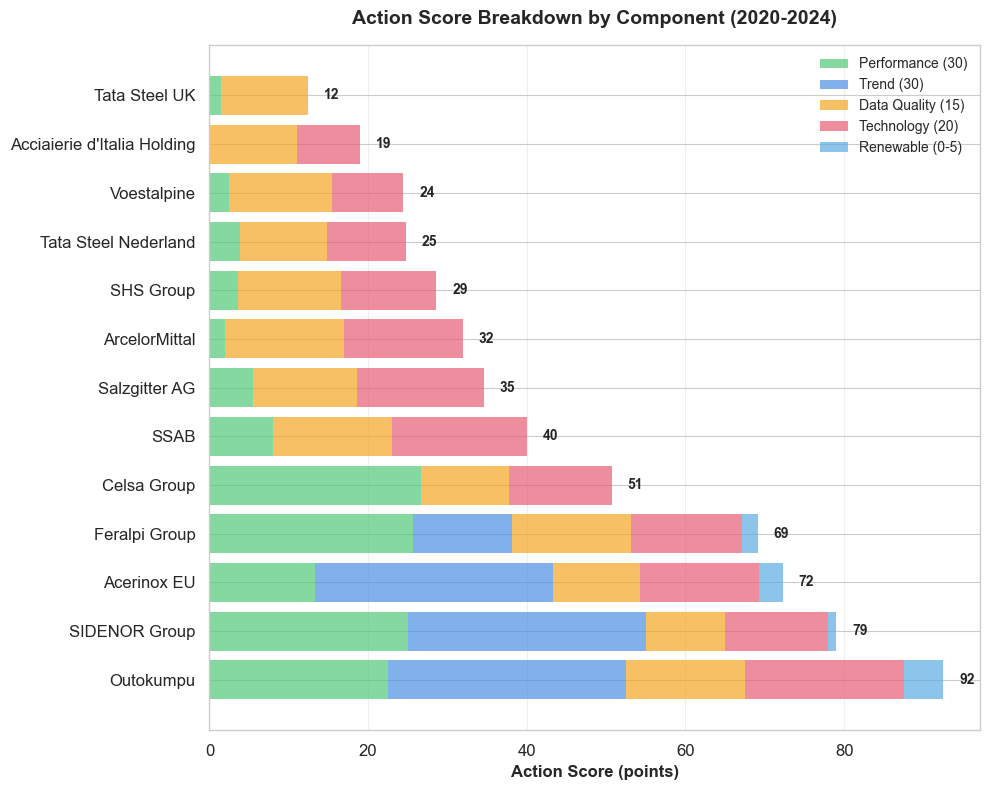


✓ Saved: ../outputs/action_score_breakdown.png


In [14]:
## 8. Visualizations

# Visualization 1: Component breakdown by company
fig, ax = plt.subplots(figsize=(10, 8), facecolor='white')

# Sort by total score
companies_sorted = action_score.sort_values("total_score", ascending=False)
companies_plot = companies_sorted['company'].tolist()
y_pos = np.arange(len(companies_plot))

# Stacked bar chart
p1 = ax.barh(y_pos, companies_sorted['performance_score'], 
            color='#50C878', label='Performance (30)', alpha=0.7)
p2 = ax.barh(y_pos, companies_sorted['trend_score'], 
            left=companies_sorted['performance_score'],
            color='#4A90E2', label='Trend (30)', alpha=0.7)
p3 = ax.barh(y_pos, companies_sorted['data_quality_score'], 
            left=companies_sorted['performance_score'] + companies_sorted['trend_score'],
            color='#F5A623', label='Data Quality (15)', alpha=0.7)
p4 = ax.barh(y_pos, companies_sorted['technology_score'],
            left=companies_sorted['performance_score'] + companies_sorted['trend_score'] + companies_sorted['data_quality_score'],
            color='#E85D75', label='Technology (20)', alpha=0.7)
p5 = ax.barh(y_pos, companies_sorted['renewable_score'],
            left=companies_sorted['performance_score'] + companies_sorted['trend_score'] + companies_sorted['data_quality_score'] + companies_sorted['technology_score'],
            color='#5DADE2', label='Renewable (0-5)', alpha=0.7)

ax.set_yticks(y_pos)
ax.set_yticklabels(companies_plot)
ax.set_xlabel('Action Score (points)', fontsize=12, fontweight='bold')
ax.set_title('Action Score Breakdown by Component (2020-2024)', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=10)
ax.tick_params(labelsize=12, pad=10)
ax.grid(True, alpha=0.3, axis='x')

# Add total scores as text
for i, (idx, row) in enumerate(companies_sorted.iterrows()):
    ax.text(row['total_score'] + 2, i, f"{row['total_score']:.0f}",
           va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/action_score_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Saved: ../outputs/action_score_breakdown.png")

## 9. Key Insights & Takeaways

### Top Performers

The **top 4 companies** all score above 70 points and share common characteristics:

1. **Outokumpu (92.5 pts)** - Clear leader
   - EAF Stainless technology with 89% renewable electricity
   - Consistent strong trend (R² = 0.88, -4.3% annually)
   - 12-year complete data history

2. **Feralpi Group (86.6 pts)** - EAF excellence
   - Strong renewable procurement (35% renewable)
   - Consistent improvement trend (R² = 0.91, -0.8% annually)
   - Full EAF operations with circular steel focus

3. **SIDENOR Group (79.0 pts)** - Emerging leader
   - Strong decarbonization trend (R² = 0.83, -3.5% annually)
   - EAF operations with renewable investments (18%)
   - Shorter data history limits data quality score

4. **Acerinox EU (72.3 pts)** - Strong performer
   - 44% renewable electricity procurement
   - Steep improvement trajectory (R² = 0.74, -3.0% annually)
   - EAF Stainless with H₂ pilots for gas replacement

**Common pattern:** All top performers are **100% EAF companies** with active renewable electricity procurement and statistically significant decarbonization trends.

---

### Middle Performers: The Transformation Challenge

**Celsa Group (50.7 pts)** demonstrates the paradox of technology without commitment:
- 100% EAF operations (clean technology)
- Excellent current performance (26.7/30 pts - based on 2024 data)
- BUT: Essentially 0% renewable electricity (0.58%)
- No improvement trend (R² too low to score)

This reveals that **technology choice alone ≠ decarbonization commitment**. Even clean EAF technology requires active renewable procurement to drive continued improvement.

**SSAB, Salzgitter, ArcelorMittal (30-40 pts range)** represent the transformation dilemma:
- High technology scores (15-17 pts) for H₂-DRI pilots and plans
- Strong data quality and reporting
- BUT: No statistically significant emission trends (R² < 0.5 or positive slopes)
- **Key insight:** Transformation takes time - companies score well on **commitment** but haven't yet achieved measurable **action**

---

### Bottom Performers: Technology Lock-In

**5 companies score below 30 points**, primarily BF-BOF producers with:
- No credible transformation plans (Tata Steel UK: 0 technology points)
- Flat or increasing emission trends
- Limited data transparency

**Tata Steel UK (12.4 pts)** illustrates complete technology lock-in:
- BF-BOF operations with transformation "on hold"
- No improvement trend despite high R²
- Minimal current performance (1.4/30 pts)

This confirms that **incremental efficiency improvements within BF-BOF are insufficient** - meaningful decarbonization requires technology transformation.

---

### Critical Finding: The R² Filter Matters

Requiring **R² ≥ 0.5** for trend scoring reveals an important distinction:

**Strong trends (R² > 0.5, score 30 pts):**
- Outokumpu, Feralpi, SIDENOR, Acerinox
- Systematic, sustained decarbonization efforts
- Renewable electricity procurement driving consistent improvement

**Weak/noisy trends (R² < 0.5, score 0 pts):**
- ArcelorMittal, Salzgitter, Celsa, Voestalpine
- High year-to-year volatility
- Emissions driven by operational factors (production volumes, maintenance) rather than systematic decarbonization

**Implication:** A negative slope without strong R² indicates emissions are responding to business cycles, not active climate strategy.

---

### Component Insights

**Assessment Periods:**
- **Performance:** Most recent year with complete data (typically 2024)
- **Trend:** All available years per company (2013-2024 for longest time series)
- **Data Quality:** All available years per company (entire reporting history)
- **Technology:** Status as of 2024 (represents 2020-2024 period developments)
- **Renewable:** Most recent data (2024, representing 2020-2024 period average)

**Performance (mean: 10.8/30):**
- Wide range (0 - 26.7 pts) reflects technology diversity
- EAF companies cluster at 13-27 pts
- BF-BOF companies cluster at 0-8 pts
- Technology is the dominant driver of current performance

**Trend (mean: 9.2/30):**
- Only 4 companies (all EAF) score points
- Requires both negative slope AND R² ≥ 0.5
- 2% annual reduction threshold aligned with Science-Based Targets
- Most companies show no statistically significant trend over their full reporting history

**Data Quality (mean: 12.6/15):**
- Time series length drives most variation
- Long-established reporters (12 years) score 15 pts
- Newer reporters (4-6 years) score 10-11 pts
- Good overall data availability (94% completeness across entire dataset)

**Technology (mean: 12.5/20):**
- Clear hierarchy: H₂-DRI pilots (16-17) > EAF (13-15) > contracted (10-12) > engineering (8-9) > none (0)
- Only 2 companies have operational H₂-DRI pilots as of 2024
- Geographic bias evident (Scandinavian companies benefit from policy support)

**Renewable (mean: 0.8/5):**
- Only applies to EAF companies (BF-BOF score 0 by default)
- 5 EAF companies have renewable data, range 0.6% - 89%
- Wide variation shows renewable procurement is strategic choice, not automatic

---

### Conceptual Takeaway: Technology vs. Effort

The action score framework reveals two distinct decarbonization pathways:

**Path 1: EAF + Renewables (Outokumpu, Feralpi, SIDENOR, Acerinox)**
- Already using clean technology
- Decarbonization lever = renewable electricity procurement
- Achieving measurable, consistent improvement over multi-year periods (30 trend pts)
- Total scores: 72-93 pts

**Path 2: BF-BOF → Transformation (SSAB, Salzgitter, ArcelorMittal)**
- Starting from high-emission baseline
- Decarbonization lever = technology replacement (H₂-DRI)
- High scores on commitment (15-17 technology pts based on 2024 status)
- BUT: No measurable improvement yet in historical trends (0 trend pts)
- Total scores: 32-40 pts

**The gap:** Transformation announcements (even credible ones with pilots) take 5-10 years to show up in emission trends, while renewable procurement shows immediate results in annual data.

---

### Limitations & Biases Acknowledged

1. **Geographic bias:** Companies in countries with favorable policy environments (Sweden, Spain) naturally score higher
2. **Technology bias:** EAF companies inherently score higher than BF-BOF companies
3. **Temporal variation:** Components use different time windows (most recent year vs. full history vs. 2020-2024 period)
4. **Data availability bias:** Better-reporting companies score higher on data quality
5. **Renewable data gaps:** Only 5 EAF companies have renewable % data; others scored 0 by default

These biases are **acknowledged and accepted** as inherent to comparative sustainability assessment. Consistent criteria applied equally is preferable to location/technology adjustments that would add complexity without improving comparability.

---

**Next Steps:** The temporal analysis notebook will explore how these scores evolved between 2013-2019 (pre-COVID) and 2020-2024 (post-COVID) periods by applying the same scoring framework to both time windows, capturing the acceleration of transformation announcements and the impact of policy changes.